In [ ]:
import itk
import numpy as np
import torch

from unigradicon import make_network
import sys
sys.path.append("./evaluations")
from utils import finetune_execute

import json
import os

import nibabel as nib
# import utils
import tqdm
import torch.nn.functional as F
import icon_registration 
import icon_registration.pretrained_models

In [2]:
clamp = [-1000, 1000]

In [3]:
def reorient(moving):
    from itk.ITKCommonBasePython import itkSpatialOrientationAdapter

    return itk.orient_image_filter(
                        moving, 
                                desired_coordinate_orientation=itk.ITKCommonBasePython.itkSpatialOrientationEnums.ValidCoordinateOrientations_ITK_COORDINATE_ORIENTATION_RAS,
                                        use_image_direction=True)

def get_image(dataset, shape):
    if dataset == "COPDGene":
        
        image_root = "/playpen-raid1/lin.tian/data/lung/dirlab_highres_350"
        case = "copd1_highres"

        image_insp = itk.imread(f"{image_root}/{case}/{case}_INSP_STD_COPD_img.nii.gz")
        image_exp = itk.imread(f"{image_root}/{case}/{case}_EXP_STD_COPD_img.nii.gz")
        seg_insp = itk.imread(f"{image_root}/{case}/{case}_INSP_STD_COPD_label.nii.gz")
        seg_exp = itk.imread(f"{image_root}/{case}/{case}_EXP_STD_COPD_label.nii.gz")
        image_insp_preprocessed = (
            icon_registration.pretrained_models.lung_network_preprocess(
                image_insp, seg_insp
            )
        )
        image_exp_preprocessed = (
            icon_registration.pretrained_models.lung_network_preprocess(image_exp, seg_exp)
        )
        return F.interpolate(torch.from_numpy(np.array(image_insp_preprocessed))[None, None], shape), F.interpolate(torch.from_numpy(np.array(image_exp_preprocessed))[None, None], shape)
    elif dataset == "OAI":
        with open("/playpen-raid2/lin.tian/projects/icon_lung/ICON/training_scripts/oai_paper_pipeline/splits/test/pair_path_list.txt") as f:
            test_pair_paths = f.readlines()
        print((len(test_pair_paths)))
        test_pair_path = test_pair_paths[0]
        test_pair_path = test_pair_path.replace("playpen", "playpen-raid").split()
        test_pair = [itk.imread(path) for path in test_pair_path]
        test_pair = [
            (
                itk.flip_image_filter(t, flip_axes=(False, False, True))
                if "RIGHT" in path
                else t
            )
            for (t, path) in zip(test_pair, test_pair_path)
        ]
        image_A, image_B, segmentation_A, segmentation_B = test_pair
        return F.interpolate(torch.from_numpy(np.array(image_A))[None, None], shape), F.interpolate(torch.from_numpy(np.array(image_B))[None, None], shape)
    elif dataset == "HCP":
        import sys
        sys.path.append('/playpen-raid2/lin.tian/projects/uniGradICON/evaluations')
        from HCP_segs import atlas_registered, get_brain_image, get_sub_seg
        import random

        print(len(atlas_registered))
        # random.seed(1)
        n_A, n_B = (random.choice(atlas_registered) for _ in range(2))
        def preprocess(image):
            # image = itk.CastImageFilter[itk.Image[itk.SS, 3], itk.Image[itk.F, 3]].New()(image)
            image = reorient(image)
            max_ = np.max(np.array(image))
            image = itk.shift_scale_image_filter(image, shift=0., scale = float(.9 / max_))
            
            #image = itk.clamp_image_filter(image, bounds=(0, 1))
            return image
        image_A, image_B = (preprocess(get_brain_image(n)) for n in (n_A, n_B))
        return F.interpolate(torch.from_numpy(np.array(image_A))[None, None], shape), F.interpolate(torch.from_numpy(np.array(image_B))[None, None], shape)
    elif dataset == "l2r_abdomen":
        import csv
        data_folder = "/playpen-raid2/lin.tian/data/learn2reg/L2R_Task3_AbdominalCT"
        with open(f"{data_folder}/pairs_val.csv", 'r') as data_info:
            csv_reader = csv.reader(data_info)
            next(csv_reader)
            test_cases = [[f"Training/img/img{int(row[0]):04d}.nii.gz", f"Training/img/img{int(row[1]):04d}.nii.gz"] for row in csv_reader]

        print(len(test_cases))
        fixed_path, moving_path = test_cases[0]
        
        fixed = np.asarray(reorient(itk.imread(os.path.join(data_folder, fixed_path))))
        moving = np.asarray(reorient(itk.imread(os.path.join(data_folder, moving_path))))

        fixed = torch.Tensor(np.array(fixed)).unsqueeze(0).unsqueeze(0)
        fixed = (torch.clamp(fixed, clamp[0], clamp[1]) - clamp[0])/(clamp[1]-clamp[0])
        fixed_in_net = F.interpolate(fixed, shape, mode='trilinear', align_corners=False)
        
        moving = torch.Tensor(np.array(moving)).unsqueeze(0).unsqueeze(0)
        moving = (torch.clamp(moving, clamp[0], clamp[1]) - clamp[0])/(clamp[1]-clamp[0])
        moving_in_net = F.interpolate(moving, shape, mode='trilinear', align_corners=False)
        return moving_in_net, fixed_in_net
    elif dataset == "l2r_abdomenMRCT":
        data_folder = "/playpen-raid2/lin.tian/data/learn2reg/AbdomenMRCT"
        with open(f"{data_folder}/AbdomenMRCT_dataset.json", 'r') as data_info:
            data_info = json.loads(data_info.read())
        test_cases = [[c["fixed"], c["moving"]] for c in data_info["registration_val"]]
        fixed_path, moving_path = test_cases[0]
        print(len(test_cases))

        def preprocess(img):
            im_min, im_max = torch.min(img), torch.quantile(img.view(-1), 0.99)
            img = torch.clip(img, im_min, im_max)
            img = (img-im_min) / (im_max-im_min)
            return img

        fixed = np.asarray(reorient(itk.imread(os.path.join(data_folder, fixed_path))))
        moving = np.asarray(reorient(itk.imread(os.path.join(data_folder, moving_path))))

        # Fixed: MRI
        fixed = torch.Tensor(np.array(fixed)).unsqueeze(0).unsqueeze(0)
        fixed = preprocess(fixed)
        fixed_in_net = F.interpolate(fixed, shape, mode='trilinear', align_corners=False)
        
        # Move: CT
        moving = torch.Tensor(np.array(moving)).unsqueeze(0).unsqueeze(0)
        moving = (torch.clamp(moving, clamp[0], clamp[1]) - clamp[0])/(clamp[1]-clamp[0])
        moving_in_net = F.interpolate(moving, shape, mode='trilinear', align_corners=False)
        return moving_in_net, fixed_in_net
    elif dataset == "l2r_CBCT":
        data_folder = "/playpen-raid2/lin.tian/data/learn2reg/ThoraxCBCT"
        with open(f"{data_folder}/ThoraxCBCT_dataset.json", 'r') as data_info:
            data_info = json.loads(data_info.read())
        test_cases = [[c["fixed"], c["moving"]] for c in data_info["registration_val"]]
        fixed_path, moving_path = test_cases[0]
        print(len(test_cases))

        fixed = np.asarray(reorient(itk.imread(os.path.join(data_folder, fixed_path))))
        moving = np.asarray(reorient(itk.imread(os.path.join(data_folder, moving_path))))

        fixed = torch.Tensor(np.array(fixed)).unsqueeze(0).unsqueeze(0)
        fixed = (torch.clamp(fixed, clamp[0], clamp[1]) - clamp[0])/(clamp[1]-clamp[0])
        fixed_in_net = F.interpolate(fixed, shape, mode='trilinear', align_corners=False)
        
        moving = torch.Tensor(np.array(moving)).unsqueeze(0).unsqueeze(0)
        moving = (torch.clamp(moving, clamp[0], clamp[1]) - clamp[0])/(clamp[1]-clamp[0])
        moving_in_net = F.interpolate(moving, shape, mode='trilinear', align_corners=False)
        return moving_in_net, fixed_in_net
    elif dataset == "l2r_NLST":
        data_folder = "/playpen-raid2/lin.tian/data/learn2reg/NLST"
        with open(f"{data_folder}/NLST_dataset.json", 'r') as data_info:
            data_info = json.loads(data_info.read())
        test_cases = [[c["fixed"], c["moving"]] for c in data_info["registration_val"]]
        fixed_path, moving_path = test_cases[0]
        print(len(test_cases))

        fixed = np.asarray(reorient(itk.imread(os.path.join(data_folder, fixed_path))))
        moving = np.asarray(reorient(itk.imread(os.path.join(data_folder, moving_path))))
        fixed_mask = np.asarray(reorient(itk.imread(os.path.join(data_folder, fixed_path.replace("imagesTr", "masksTr")))))
        moving_mask = np.asarray(reorient(itk.imread(os.path.join(data_folder, moving_path.replace("imagesTr", "masksTr")))))

        fixed = torch.Tensor(np.array(fixed)).unsqueeze(0).unsqueeze(0)
        fixed = (torch.clamp(fixed, clamp[0], clamp[1]) - clamp[0])/(clamp[1]-clamp[0])
        fixed = fixed * torch.Tensor(fixed_mask).unsqueeze(0).unsqueeze(0)
        fixed_in_net = F.interpolate(fixed, shape, mode='trilinear', align_corners=False)
        
        moving = torch.Tensor(np.array(moving)).unsqueeze(0).unsqueeze(0)
        moving = (torch.clamp(moving, clamp[0], clamp[1]) - clamp[0])/(clamp[1]-clamp[0])
        moving = moving * torch.Tensor(moving_mask).unsqueeze(0).unsqueeze(0)
        moving_in_net = F.interpolate(moving, shape, mode='trilinear', align_corners=False)
        return moving_in_net, fixed_in_net
    elif dataset == "l2r_OASIS":
        data_folder = "/playpen-raid2/lin.tian/data/learn2reg/OASIS"

        import glob
        cases = sorted(glob.glob(f"{data_folder}/val/img????.nii.gz"))
        test_cases = []
        for i in range(len(cases[:-1])):
            test_cases.append([cases[i], cases[i+1]])

        print(len(test_cases))
        
        fixed_path, moving_path = test_cases[0]
        def preprocess(img):
            im_min, im_max = torch.min(img), torch.quantile(img.view(-1), 0.99)
            img = torch.clip(img, im_min, im_max)
            img = (img-im_min) / (im_max-im_min)
            return img

        # fixed = np.asarray(nib.load(os.path.join(data_folder, fixed_path)).get_fdata()).copy()
        # moving = np.asarray(nib.load(os.path.join(data_folder, moving_path)).get_fdata()).copy()
        fixed = np.asarray(itk.imread(os.path.join(data_folder, fixed_path)))
        moving = np.asarray(itk.imread(os.path.join(data_folder, moving_path)))
        # fixed_mask = np.asarray(itk.imread(os.path.join(args.data_folder, fixed_path.replace("imagesTr", "masksTr"))))
        # moving_mask = np.asarray(itk.imread(os.path.join(args.data_folder, moving_path.replace("imagesTr", "masksTr"))))

        fixed = torch.Tensor(np.array(fixed)).unsqueeze(0).unsqueeze(0)
        fixed = preprocess(fixed)
        # fixed = fixed * torch.Tensor(fixed_mask).unsqueeze(0).unsqueeze(0)
        fixed_in_net = F.interpolate(fixed, shape, mode='trilinear', align_corners=False)
        
        moving = torch.Tensor(np.array(moving)).unsqueeze(0).unsqueeze(0)
        moving = preprocess(moving)
        # moving = moving * torch.Tensor(moving_mask).unsqueeze(0).unsqueeze(0)
        moving_in_net = F.interpolate(moving, shape, mode='trilinear', align_corners=False)
        return moving_in_net, fixed_in_net
    elif dataset == "IXI":
        atlas_dir = '/playpen-raid2/Data/IXI/IXI_data/atlas.pkl'
        test_dir = '/playpen-raid2/Data/IXI/IXI_data/Test/'
        import sys
        sys.path.append('/playpen-raid2/lin.tian/projects/uniGradICON/evaluations')
        import IXI_utils
        import glob
        from IXI_utils import IXIBrainInferDataset, NumpyType, Seg_norm, Compose
        test_composed = Compose([Seg_norm(),
                                NumpyType((np.float32, np.int16)),
                                ])
        test_set = IXIBrainInferDataset(glob.glob(test_dir + '*.pkl'), atlas_dir, transforms=test_composed)
        test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=False, num_workers=1, pin_memory=True, drop_last=True)
        moving, fixed, _, _, _ = next(iter(test_loader))
        moving = moving.permute(0, 1, 4, 3, 2).contiguous()
        fixed = fixed.permute(0, 1, 4, 3, 2).contiguous()
        print(len(test_set))

        def preprocess(img):
            im_min, im_max = torch.min(img), torch.quantile(img.view(-1), 0.99)
            img = torch.clip(img, im_min, im_max)
            img = (img-im_min) / (im_max-im_min)
            return img
        moving = preprocess(moving)
        moving_in_net = torch.nn.functional.interpolate(moving, shape, mode='trilinear', align_corners=False)
        fixed = preprocess(fixed)
        fixed_in_net = torch.nn.functional.interpolate(fixed, shape, mode='trilinear', align_corners=False)
        return moving_in_net, fixed_in_net
    elif dataset == "ACDC":
        import glob
        import sys
        sys.path.append('/playpen-raid2/lin.tian/projects/uniGradICON/evaluations')
        from ACDCMM_eval import to_itk, permute
        from ACDCMM_eval import preprocess as acdc_preprocess
        ACDC_cases = sorted(glob.glob('/playpen-raid2/lin.tian/data/ACDC/database/testing/patient*/'))
        case = ACDC_cases[0]
        case_pathes = {}
        case_id = case.split("/")[-2]

        with open(os.path.join(case, "Info.cfg")) as f:
            for line in f.readlines():
                if "ES" in line:
                    ES_id = int(line.split(":")[-1][:-1])
                    case_pathes["ES"] = os.path.join(case, f"{case_id}_frame{ES_id:02d}.nii.gz")
                    case_pathes["ES_seg"] = os.path.join(case, f"{case_id}_frame{ES_id:02d}_gt.nii.gz")
                    
                elif "ED" in line:
                    ED_id = int(line.split(":")[-1][:-1])
                    case_pathes["ED"] = os.path.join(case, f"{case_id}_frame{ED_id:02d}.nii.gz")
                    case_pathes["ED_seg"] = os.path.join(case, f"{case_id}_frame{ED_id:02d}_gt.nii.gz")
        
        image_A = nib.load(case_pathes["ES"])
        image_A = torch.Tensor(np.array(acdc_preprocess(permute(to_itk(image_A.get_fdata(), image_A.affine)))))[None, None]
        image_B = nib.load(case_pathes["ED"])
        image_B = torch.Tensor(np.array(acdc_preprocess(permute(to_itk(image_B.get_fdata(), image_B.affine)))))[None, None]

        moving_in_net = torch.nn.functional.interpolate(image_A, shape, mode='trilinear', align_corners=False)
        fixed_in_net = torch.nn.functional.interpolate(image_B, shape, mode='trilinear', align_corners=False)
        return moving_in_net, fixed_in_net
    # elif dataset == "MM":
    #     from ACDCMM_eval import to_itk, permute, preprocess
    #     MM_cases = sorted(glob.glob(f'{args.MM_path}/Validation/*/*_sa.nii.gz'))
    #     df = pd.read_csv(f"{args.MM_path}/211230_MMs_Dataset_information_diagnosis_opendataset.csv")
    #     case_pathes = {}
    #     case_id = case.split("/")[-1].split("_")[0]

    #     ES_slice_id = df[df["External code"] == case_id]["ES"].values[0]
    #     ED_slice_id = df[df["External code"] == case_id]["ED"].values[0]
    #     case_pathes["ES"] = int(ES_slice_id)
    #     case_pathes["ED"] = int(ED_slice_id)
    #     case_pathes["img"] = case
    #     case_pathes["seg"] = case.split(".")[0] + "_gt.nii.gz"
    #     test_cases[f"MM.{case_id}"] = case_pathes

    #     image_nib = nib.load(test_cases[case]["img"])
    #     image = image_nib.get_fdata()
    #     image_A = torch.Tensor(np.array(preprocess(permute(to_itk(image[:,:,:,test_cases[case]["ES"]], image_nib.affine)))))[None, None]
    #     image_B = torch.Tensor(np.array(preprocess(permute(to_itk(image[:,:,:,test_cases[case]["ED"]], image_nib.affine)))))[None, None]

    #     moving_in_net = torch.nn.functional.interpolate(image_A, shape, mode='trilinear', align_corners=False)
    #     fixed_in_net = torch.nn.functional.interpolate(image_B, shape, mode='trilinear', align_corners=False)
    #     return moving_in_net, fixed_in_net
    else:
        print("Dataset not found")
        return None, None






In [6]:
datasets = ["COPDGene", "OAI", "HCP", "l2r_abdomen", "l2r_abdomenMRCT", "l2r_CBCT", "l2r_NLST", "l2r_OASIS", "IXI", "ACDC"]
# datasets = ["ACDC"]



device = "cuda:0"
net = make_network((1,1,175, 175, 175), include_last_step=True)
weights = torch.load("/playpen-raid2/lin.tian/projects/uniGradICON/pretrained_unigradicon/Step_2_final.trch", map_location="cpu")


In [7]:
for d in datasets:
    print(d)
    moving, fixed = get_image(d, [175, 175, 175])

ACDC


In [7]:
res = {}
for d in datasets:
    print(d)
    net.regis_net.load_state_dict(weights, strict=True)
    net.to(device)
    net.eval()

    moving, fixed = get_image(d, [175, 175, 175])
    with torch.no_grad():
        net(moving.to(device), fixed.to(device))
        res[d] = [moving, fixed, net.warped_image_A.cpu(), net.warped_image_B.cpu(), net.phi_AB_vectorfield.cpu(), net.phi_BA_vectorfield.cpu()]
    
    finetune_execute(net, moving.to(device), fixed.to(device), steps=50)

    res[d] += [net.warped_image_A.cpu(), net.warped_image_B.cpu(), net.phi_AB_vectorfield.cpu(), net.phi_BA_vectorfield.cpu()]
    

COPDGene


__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword


ICONLoss(all_loss=tensor(1.5996, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0129, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.5802, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0014, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(68., device='cuda:0'))
ICONLoss(all_loss=tensor(1.5924, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0114, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.5753, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0014, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(58., device='cuda:0'))
ICONLoss(all_loss=tensor(1.5885, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0104, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.5729, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0014, device='cuda:0', grad_fn=<MeanBackward0>), flip

__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword


ICONLoss(all_loss=tensor(1.2120, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.1049, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.0546, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0025, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(126., device='cuda:0'))
ICONLoss(all_loss=tensor(1.1743, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0799, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.0545, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0025, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(93., device='cuda:0'))
ICONLoss(all_loss=tensor(1.1621, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0723, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.0537, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0025, device='cuda:0', grad_fn=<MeanBackward0>), fli

__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword


ICONLoss(all_loss=tensor(1.3616, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0136, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.3413, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0003, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(3., device='cuda:0'))
ICONLoss(all_loss=tensor(1.3605, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0160, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.3366, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0003, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(0., device='cuda:0'))
ICONLoss(all_loss=tensor(1.3521, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0126, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(1.3333, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(0.0003, device='cuda:0', grad_fn=<MeanBackward0>), flips=

__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
__array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword


ICONLoss(all_loss=tensor(0.1487, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0266, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(0.1089, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(1.5912e-05, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(44., device='cuda:0'))
ICONLoss(all_loss=tensor(0.1273, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0202, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(0.0971, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(1.2829e-05, device='cuda:0', grad_fn=<MeanBackward0>), flips=tensor(0., device='cuda:0'))
ICONLoss(all_loss=tensor(0.1198, device='cuda:0', grad_fn=<AddBackward0>), inverse_consistency_loss=tensor(0.0178, device='cuda:0', grad_fn=<AddBackward0>), similarity_loss=tensor(0.0931, device='cuda:0', grad_fn=<AddBackward0>), transform_magnitude=tensor(1.1330e-05, device='cuda:0', grad_fn=<MeanBackwa

In [49]:
import matplotlib.pyplot as plt

def show_as_grid(ax, phi, linewidth=1, stride=8, flip=False):
    data_size = phi.size()[1:]
    # phi = phi[:,20:160,20:160]
    plot_phi = phi[:, ::stride, ::stride].detach().cpu() - 0.5
    # plot_phi = data_size * phi.detach().cpu() - 0.5
    # ax.set_xlim([20,160])
    # axes.set_ylim([160, 20])
    ax.set_xlim([-0.5, phi.size()[-1] - 0.5])
    ax.set_ylim([phi.size()[-2] - 0.5, -0.5])
    N = plot_phi.size()[-1]
    colors = plt.cm.viridis(np.linspace(0,1,N))
    ax.plot(plot_phi[1], plot_phi[0], linewidth=linewidth, alpha=0.4, color='orange')
    ax.plot(
        plot_phi[1].transpose(0, 1), plot_phi[0].transpose(0, 1), linewidth=linewidth, alpha=0.4, color='orange'
    )

    if flip:
        # ax.set_xlim([0,data_size[0]])
        ax.set_ylim([0, data_size[0]])

def show_as_grid_contour(ax, phi, linewidth=1, stride=8, flip=False):
    data_size = phi.size()[1:]
    # phi = phi[:,20:160,20:160]
    plot_phi = phi.cpu() - 0.5
    # plot_phi = phi[:, ::stride, ::stride].detach().cpu() - 0.5
    # plot_identity = identity[:, ::stride, ::stride].detach().cpu() - 0.5
    # plot_phi = data_size * phi.detach().cpu() - 0.5
    # ax.set_xlim([20,160])
    # axes.set_ylim([160, 20])
    # ax.set_xlim([-0.5, phi.size()[-1] - 0.5])
    # ax.set_ylim([phi.size()[-2] - 0.5, -0.5])
    N = plot_phi.size()[-1]
    ax.contour(plot_phi[1], np.linspace(0, N, int(N/stride)), linewidths=linewidth, alpha=0.8)
    ax.contour(plot_phi[0], np.linspace(0, N, int(N/stride)), linewidths=linewidth, alpha=0.8)
    # ax.plot(plot_phi[1], plot_phi[0], linewidth=linewidth, alpha=0.4, color='orange')
    # ax.plot(
    #     plot_phi[1].transpose(0, 1), plot_phi[0].transpose(0, 1), linewidth=linewidth, alpha=0.4, color='orange'
    # )

    if flip:
        # ax.set_xlim([0,data_size[0]])
        ax.set_ylim([0, data_size[0]])

def folds_map(phi):
    if len(phi.size()) == 5:
        a = (phi[:, :, 1:, 1:, 1:] - phi[:, :, :-1, 1:, 1:]).detach()
        b = (phi[:, :, 1:, 1:, 1:] - phi[:, :, 1:, :-1, 1:]).detach()
        c = (phi[:, :, 1:, 1:, 1:] - phi[:, :, 1:, 1:, :-1]).detach()

        dV = torch.sum(torch.cross(a, b, 1) * c, axis=1, keepdims=True)

        return dV

def get_slice_indices(slice_dim: int, idx: int) -> tuple:
    """
    Returns slice indices for a 3D image based on the slice dimension and index.
    
    Args:
        slice_dim (int): Dimension to slice (0, 1, or 2)
        idx (int): Index to select in the slice dimension
    
    Returns:
        tuple: A tuple containing ([dim1,dim2], slice indices)
        where [dim1,dim2] are the dimensions to keep for 2D visualization
    """
    if slice_dim == 0:
        return [0, [1, 2], idx, slice(None), slice(None)]
    elif slice_dim == 1: 
        return [0, [0, 2], slice(None), idx, slice(None)]
    elif slice_dim == 2:
        return [0, [0, 1], slice(None), slice(None), idx]
    else:
        raise ValueError(f"Invalid slice_dim {slice_dim}. Must be 0, 1 or 2.")

from matplotlib.colors import LinearSegmentedColormap

color_min    = "red" #"#B56BC3"
color_center = "black" #"black"
color_max    = "green" #"#67B46B"
cmap = LinearSegmentedColormap.from_list(
    "cmap_name",
    [color_min, color_center, color_max],
)
cmap = "managua" #"vanimo"

def show_pair(moving, fixed, warped, phi, warped_io, phi_io, axes, slice_dim, idx, flip=False):
    phi_scaled = phi * (torch.tensor((175, 175, 175), dtype=torch.float32).unsqueeze(0).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)-1)
    phi_io_scaled = phi_io * (torch.tensor((175, 175, 175), dtype=torch.float32).unsqueeze(0).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)-1)
    if flip:
        origin = 'lower'
    else:
        origin = 'upper'
    
    slice_idx = [0,0,] + [slice(None),] * slice_dim + [idx,] + [slice(None)] * (3 - slice_dim - 1)
    phi_slice_idx = get_slice_indices(slice_dim, idx)
    moving_2d = moving.cpu()[slice_idx]
    fixed_2d = fixed.cpu()[slice_idx]
    warped_2d = warped.cpu()[slice_idx]
    warped_io_2d = warped_io.cpu()[slice_idx]
    vmin = min(moving_2d.min(), fixed_2d.min(), warped_2d.min())
    vmax = max(moving_2d.max(), fixed_2d.max(), warped_2d.max())

    axes[0].imshow(moving_2d, cmap="gray", origin=origin, vmin=vmin, vmax=vmax)
    axes[1].imshow(fixed_2d, cmap="gray", origin=origin, vmin=vmin, vmax=vmax)
    axes[2].imshow(warped_2d, cmap="gray", origin=origin, vmin=vmin, vmax=vmax)
    axes[3].imshow(fixed_2d, cmap="gray", origin=origin, vmin=vmin, vmax=vmax)
    # show_as_grid(axes[3], phi_scaled[0, [0,2], :, idx], linewidth=0.3, stride=4, flip=flip)
    show_as_grid_contour(axes[3], phi_scaled[phi_slice_idx], linewidth=0.6, stride=4, flip=flip)
    axes[6].imshow(fixed_2d-moving_2d, origin=origin, vmin=-vmax, vmax=vmax, cmap=cmap)
    axes[7].imshow(fixed_2d-warped_2d, origin=origin, vmin=-vmax, vmax=vmax, cmap=cmap)

    # Show IO
    axes[4].imshow(warped_io_2d, cmap="gray", origin=origin, vmin=vmin, vmax=vmax)
    axes[5].imshow(fixed_2d, cmap="gray", origin=origin, vmin=vmin, vmax=vmax)
    # show_as_grid(axes[3], phi_scaled[0, [0,2], :, idx], linewidth=0.3, stride=4, flip=flip)
    show_as_grid_contour(axes[5], phi_io_scaled[phi_slice_idx], linewidth=0.6, stride=4, flip=flip)
    axes[8].imshow(fixed_2d-warped_io_2d, origin=origin, vmin=-vmax, vmax=vmax, cmap=cmap)

In [26]:
# datasets = ["COPDGene"]
# datasets = ["COPDGene", "OAI", "HCP", "l2r_abdomen"]
# datasets = ["COPDGene", "OAI", "HCP", "l2r_abdomen", "l2r_abdomenMRCT", "l2r_CBCT", "l2r_NLST", "l2r_OASIS", "IXI"]
datasets = ["COPDGene", "OAI", "HCP", "l2r_abdomen", "l2r_abdomenMRCT", "l2r_CBCT", "l2r_NLST", "l2r_OASIS", "IXI"]

datasets_name = {
    "COPDGene":"DirLab \n Intra-subject", 
    "OAI":"OAI \n Inter-subject", "HCP":"HCP  \n Inter-subject", 
    "l2r_abdomen":"L2R-Abdomen \n Inter-subject", 
    "l2r_abdomenMRCT":"L2R-CTMRI \n Inter-subject", 
    "l2r_CBCT":"L2R-CBCT \n Intra-subject", 
    "l2r_NLST":"L2R-NLST \n Intra-subject", 
    "l2r_OASIS":"L2R-OASIS \n Inter-subject", 
    "IXI":"IXI \n Atlas-subject",
    "ACDC":"ACDC \n Inter-subject",}

datasets_flip = {
    "COPDGene":False, 
    "OAI":False, "HCP":False, 
    "l2r_abdomen":False, 
    "l2r_abdomenMRCT":False, 
    "l2r_CBCT":False, 
    "l2r_NLST":False, 
    "l2r_OASIS":False, 
    "IXI":False,
    "ACDC":False}

datasets_slice_dim = {
    "COPDGene":1, 
    "OAI":0, "HCP":0, 
    "l2r_abdomen":1, 
    "l2r_abdomenMRCT":1, 
    "l2r_CBCT":0, 
    "l2r_NLST":0, 
    "l2r_OASIS":1, 
    "IXI":1,
    "ACDC":2}

datasets_slice_idx = {
    "COPDGene":90, 
    "OAI":80, "HCP":100,
    "l2r_abdomen":80, 
    "l2r_abdomenMRCT":80, 
    "l2r_CBCT":80, 
    "l2r_NLST":80, 
    "l2r_OASIS":80, 
    "IXI":80,
    "ACDC":80}

datasets_slice_dim_2 = {
    "COPDGene":0, 
    "OAI":1, "HCP":1, 
    "l2r_abdomen":0, 
    "l2r_abdomenMRCT":0, 
    "l2r_CBCT":1, 
    "l2r_NLST":1, 
    "l2r_OASIS":0, 
    "IXI":0,
    "ACDC":1}

datasets_slice_idx_2 = {
    "COPDGene":90, 
    "OAI":80, "HCP":80,
    "l2r_abdomen":80, 
    "l2r_abdomenMRCT":80, 
    "l2r_CBCT":80, 
    "l2r_NLST":80, 
    "l2r_OASIS":80, 
    "IXI":80,
    "ACDC":80}

datasets_in_dist = {
    "COPDGene":1, 
    "OAI":1, "HCP":1,
    "l2r_abdomen":1, 
    "l2r_abdomenMRCT":0, 
    "l2r_CBCT":0, 
    "l2r_NLST":0, 
    "l2r_OASIS":0, 
    "IXI":0,
    "ACDC":0}

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an erro

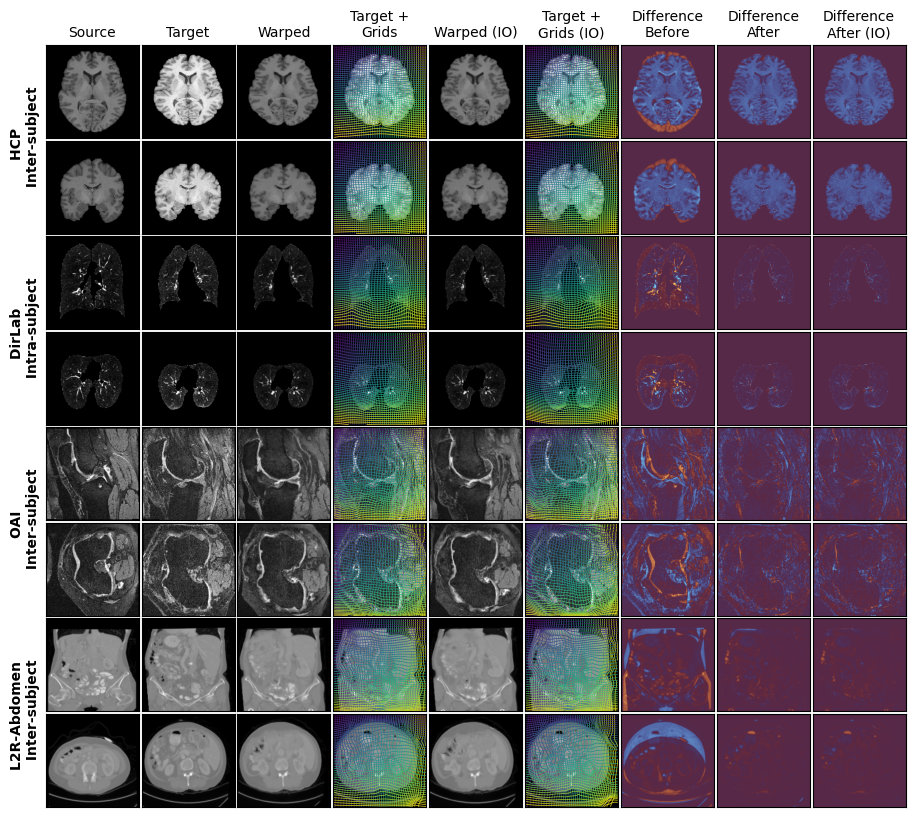

In [50]:
import matplotlib.gridspec as gridspec

datasets = ["HCP","COPDGene", "OAI", "l2r_abdomen"]
font_size = 10

fig, axes = plt.subplots(len(datasets)*2, 9, figsize=(9,len(datasets)*2))

for i, d in enumerate(datasets):
    show_pair(res[d][0], res[d][1], res[d][2], res[d][4], res[d][6], res[d][8], axes[i*2], datasets_slice_dim[d], datasets_slice_idx[d], flip=datasets_flip[d])
    show_pair(res[d][0], res[d][1], res[d][2], res[d][4], res[d][6], res[d][8], axes[i*2+1], datasets_slice_dim_2[d], datasets_slice_idx_2[d], flip=datasets_flip[d])
    # if datasets_in_dist[d] == 1:
    #     axes[i*2,0].set_ylabel(datasets_name[d], fontdict={"color":"orange", "fontweight":"bold"})
    # else:
    #     axes[i*2,0].set_ylabel(datasets_name[d], fontdict={"color":"green", "fontweight":"bold"})
    axes[i*2,0].set_ylabel(datasets_name[d], y=-0.01, fontdict={"fontsize":font_size, "fontweight":"bold"})

axes[0,0].set_title('Source', fontsize=font_size)
axes[0,1].set_title('Target', fontsize=font_size)
axes[0,2].set_title('Warped', fontsize=font_size)
axes[0,3].set_title('Target +\nGrids', fontsize=font_size)
axes[0,4].set_title('Warped (IO)', fontsize=font_size)
axes[0,5].set_title('Target +\nGrids (IO)', fontsize=font_size)
axes[0,6].set_title('Difference\nBefore', fontsize=font_size)
axes[0,7].set_title('Difference\nAfter', fontsize=font_size)
axes[0,8].set_title('Difference\nAfter (IO)', fontsize=font_size)

for axe in axes:
    for a in axe:
        a.set_xticks([])
        a.set_yticks([])

# plt.subplots_adjust(hspace=0.01, wspace=0)
plt.tight_layout(pad=0.1)
# plt.show()
plt.savefig("Registration_example_in_distribution_with_io.png", dpi=300, bbox_inches='tight')

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an erro

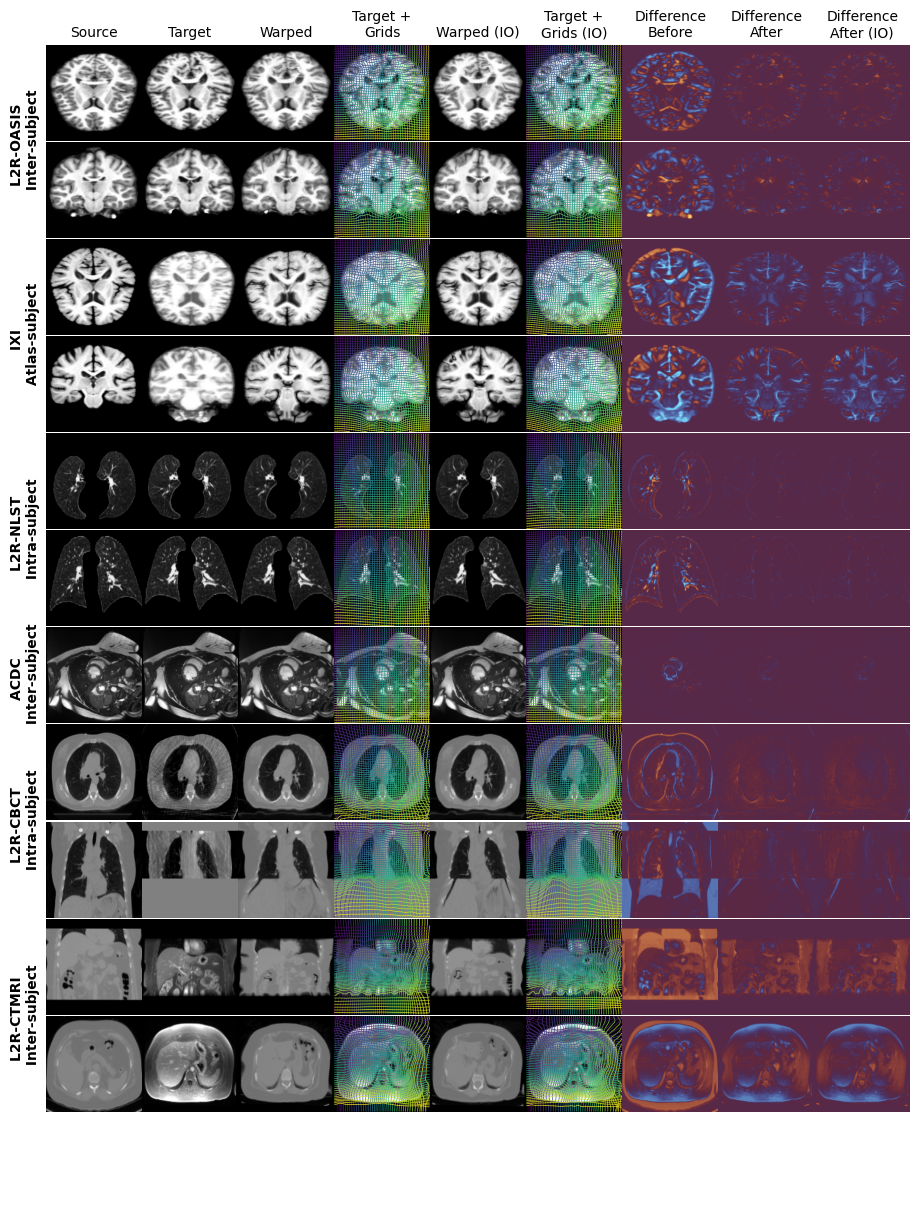

In [64]:
datasets = ["l2r_OASIS", "IXI", "l2r_NLST", "ACDC", "l2r_CBCT", "l2r_abdomenMRCT"]
font_size = 10

fig, axes = plt.subplots(len(datasets)*2, 9, figsize=(9,len(datasets)*2))

axe_id = 0
for i, d in enumerate(datasets):
    show_pair(res[d][0], res[d][1], res[d][2], res[d][4], res[d][6], res[d][8], axes[axe_id], datasets_slice_dim[d], datasets_slice_idx[d], flip=datasets_flip[d])
    axe_id += 1
    if d != "ACDC":
        show_pair(res[d][0], res[d][1], res[d][2], res[d][4], res[d][6], res[d][8], axes[axe_id], datasets_slice_dim_2[d], datasets_slice_idx_2[d], flip=datasets_flip[d])
        axes[axe_id-1,0].set_ylabel(datasets_name[d], y=-0.01, fontdict={"fontsize":font_size, "fontweight":"bold"})
        axe_id += 1
    else:
        axes[axe_id-1,0].set_ylabel(datasets_name[d], fontdict={"fontsize":font_size, "fontweight":"bold"})

axes[0,0].set_title('Source', fontsize=font_size)
axes[0,1].set_title('Target', fontsize=font_size)
axes[0,2].set_title('Warped', fontsize=font_size)
axes[0,3].set_title('Target +\nGrids', fontsize=font_size)
axes[0,4].set_title('Warped (IO)', fontsize=font_size)
axes[0,5].set_title('Target +\nGrids (IO)', fontsize=font_size)
axes[0,6].set_title('Difference\nBefore', fontsize=font_size)
axes[0,7].set_title('Difference\nAfter', fontsize=font_size)
axes[0,8].set_title('Difference\nAfter (IO)', fontsize=font_size)

for axe in axes:
    for a in axe:
        a.set_xticks([])
        a.set_yticks([])
        a.set_frame_on(False)

# plt.subplots_adjust(hspace=0.01, wspace=0.01)
plt.tight_layout(pad=0)
# plt.show()
plt.savefig("Registration_example_ood_with_io.png", dpi=300, bbox_inches='tight')

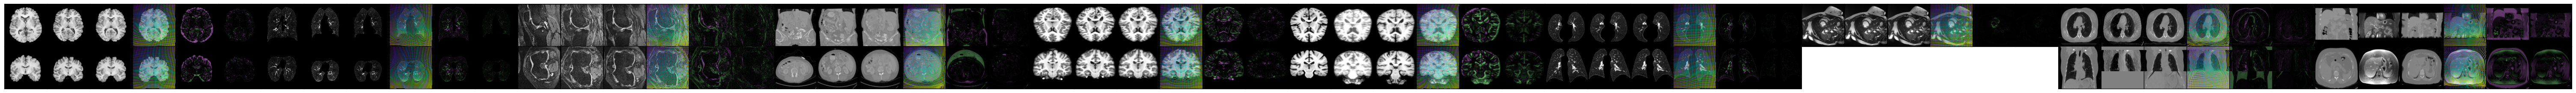

In [ ]:
datasets = ["HCP","COPDGene", "OAI", "l2r_abdomen","l2r_OASIS", "IXI", "l2r_NLST", "ACDC", "l2r_CBCT", "l2r_abdomenMRCT"]
font_size = 10

fig, axes = plt.subplots(2,len(datasets)*6, figsize=(6*len(datasets),2))

axe_id = 0
for i, d in enumerate(datasets):
    show_pair(res[d][0], res[d][1], res[d][2], res[d][4], axes[0][axe_id*6:(axe_id+1)*6], datasets_slice_dim[d], datasets_slice_idx[d], flip=datasets_flip[d])
    if d != "ACDC":
        show_pair(res[d][0], res[d][1], res[d][2], res[d][4], axes[1][axe_id*6:(axe_id+1)*6], datasets_slice_dim_2[d], datasets_slice_idx_2[d], flip=datasets_flip[d])
        # axes[axe_id-1,0].set_ylabel(datasets_name[d], y=-0.01, fontdict={"fontsize":font_size, "fontweight":"bold"})
    else:
        for ax in axes[1][axe_id*6:(axe_id+1)*6]:
            ax.set_visible(False)
    axe_id += 1
    # else:
        # axes[axe_id-1,0].set_ylabel(datasets_name[d], fontdict={"fontsize":font_size, "fontweight":"bold"})

    # axes[0,0].set_title('Source', fontsize=font_size)
    # axes[0,1].set_title('Target', fontsize=font_size)
    # axes[0,2].set_title('Warped', fontsize=font_size)
    # axes[0,3].set_title('Target+Grids', fontsize=font_size)
    # axes[0,4].set_title('Difference\nBefore', fontsize=font_size)
    # axes[0,5].set_title('Difference\nAfter', fontsize=font_size)

for axe in axes:
    for a in axe:
        a.set_xticks([])
        a.set_yticks([])

# plt.subplots_adjust(hspace=0.01, wspace=0)
plt.tight_layout(pad=0.)
# plt.show()
# plt.savefig("uniGradICON_teaser.png", dpi=150, bbox_inches='tight')

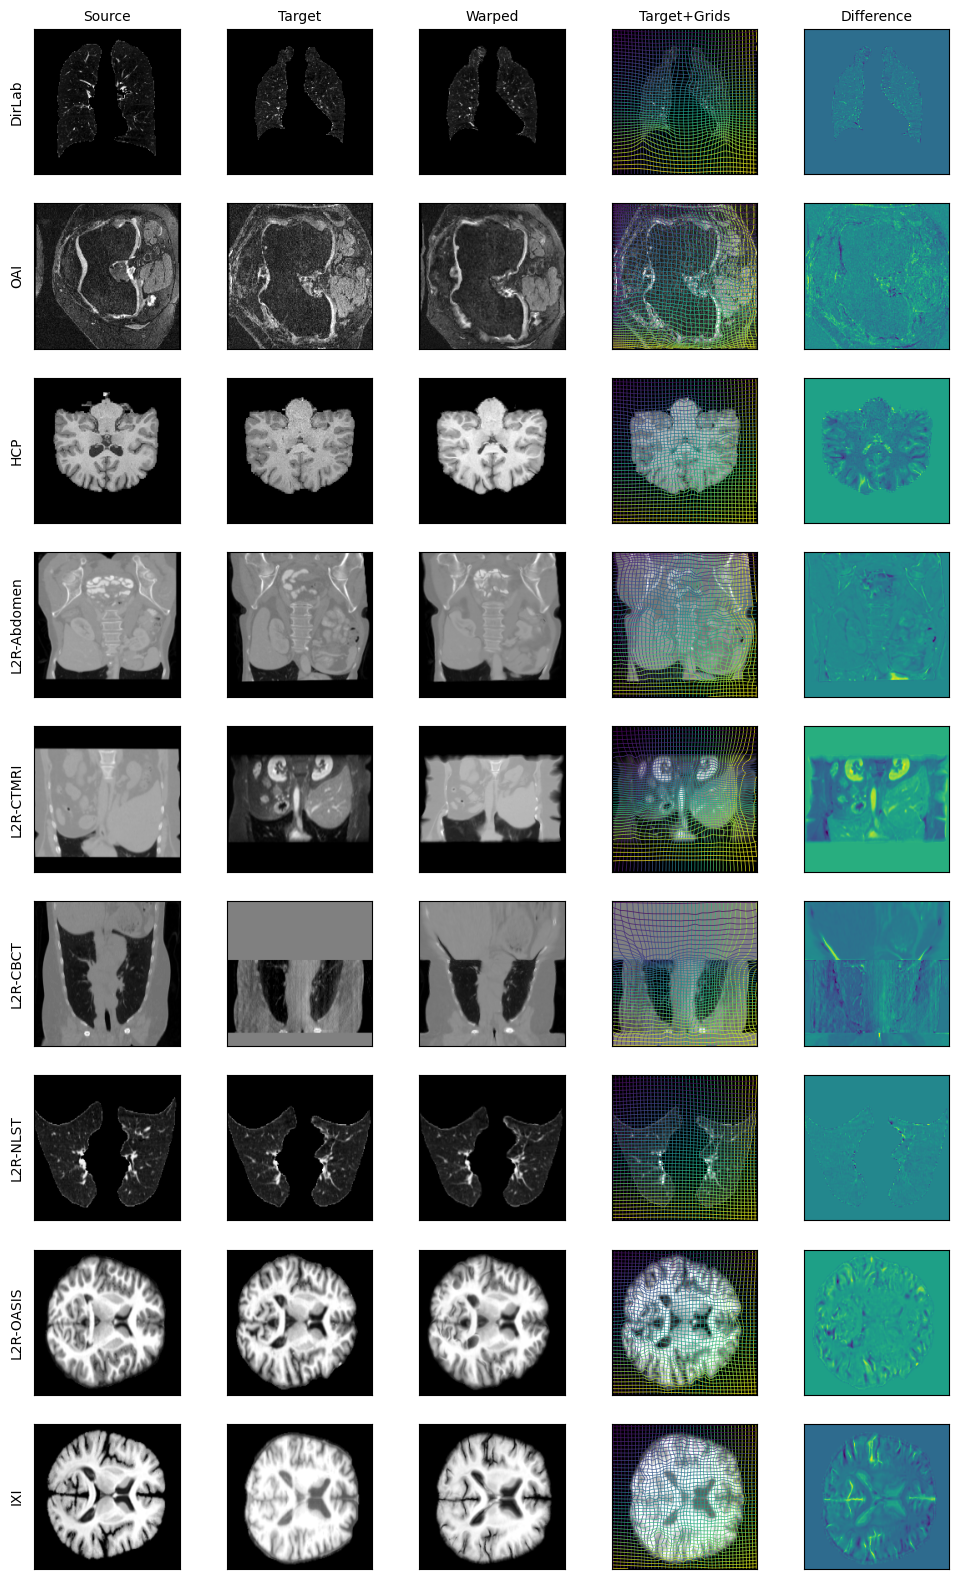

In [8]:
fig, axes = plt.subplots(len(datasets),5, figsize=(12,20))
# fig, axes = plt.subplots(len(datasets),5, figsize=(12,7))
idx_in_batch = 0
slice_idx = 80

for i, d in enumerate(datasets):
    # show_pair(res[d][0], res[d][1], res[d][2], res[d][4], axes[i], slice_idx, flip=datasets_flip[d])
    show_pair(res[d][0], res[d][1], res[d][2], res[d][4], axes[i], slice_idx, flip=False)
    axes[i,0].set_ylabel(datasets_name[d])



font_size = 10
axes[0,0].set_title('Source', fontsize=font_size)
axes[0,1].set_title('Target', fontsize=font_size)
axes[0,2].set_title('Warped', fontsize=font_size)
axes[0,3].set_title('Target+Grids', fontsize=font_size)
axes[0,4].set_title('Difference', fontsize=font_size)
for axe in axes:
    for a in axe:
        a.set_xticks([])
        a.set_yticks([])
# plt.show()
plt.savefig("Registration_examples.pdf", dpi=300, bbox_inches='tight')